# Análisis Exploratorio de Datos (EDA) - Dataset de Videos de YouTube para Niños

En este notebook se analiza el dataset de videos de YouTube para detectar contenido inapropiado para niños.

## Descripción del Dataset

**Dataset principal para ENTRENAMIENTO: dataset_groundtruth.csv**
- 4,797 videos anotados manualmente por humanos
- Distribución: 1,513 suitable, 929 disturbing, 419 restricted, 1,936 irrelevant
- Etiquetas 100% confiables para entrenamiento de modelos de ML
- Ubicación: ../dataset_disturbed_youtube_kids/dataset_groundtruth.csv

**Datasets adicionales para COMPROBACIÓN DE CONSISTENCIA (primeras 1,000 líneas):**
- elsagate_related_videos_parts/ (5 partes .json.gz): ~233K videos
- other_child_related_videos_parts/ (3 partes .json.gz): ~155K videos
- random_videos_parts/ (8 partes .json.gz): ~482K videos
- popular_videos.json.gz: ~11K videos

**Nota**: Los datasets adicionales se usarán para comprobación de consistencia y predicciones con el modelo ya entrenado (sin etiquetas humanas, salvo los videos que ya están en el ground truth). Se analizan las primeras 1,000 líneas del primer archivo de cada conjunto.


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import gzip
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

# Ruta base de los datasets
DATA_PATH = '../dataset_disturbed_youtube _for_kids'

# PARTE 1: EDA DE GROUNDTRUTH.CSV (DATASET DE ENTRENAMIENTO)

## 1. Carga de Datos de Entrenamiento

In [2]:
# Cargar ground truth (dataset principal con etiquetas manuales)
print("Cargando dataset de ENTRENAMIENTO...")
groundtruth_path = os.path.join(DATA_PATH, 'dataset_groundtruth.csv')
df_train = pd.read_csv(groundtruth_path)

print(f"• dataset_groundtruth.csv: {len(df_train)} videos (anotados manualmente)")
print(f"Columnas: {list(df_train.columns)}")

Cargando dataset de ENTRENAMIENTO...
• dataset_groundtruth.csv: 4797 videos (anotados manualmente)
Columnas: ['video_id', 'title', 'description', 'channel_id', 'channel_title', 'published_at', 'category_id', 'tags', 'duration_iso', 'duration_seconds', 'definition', 'caption', 'licensed_content', 'view_count', 'like_count', 'dislike_count', 'comment_count', 'favorite_count', 'classification_label', 'prediction', 'is_ground_truth', 'source_dataset']


## 2. Distribución de Clases en Dataset de Entrenamiento

In [3]:
# Contar etiquetas de clasificación (ground truth)
print("DISTRIBUCIÓN DE CLASES EN GROUND TRUTH (ENTRENAMIENTO)")
print("="*60)

label_counts = df_train['classification_label'].value_counts()

print(f"Total de videos de entrenamiento: {len(df_train):,}")
print(f"\nDistribución de clases:")
for label, count in label_counts.items():
    print(f" – {label}: {count:,} ({count/len(df_train)*100:.1f}%)")

DISTRIBUCIÓN DE CLASES EN GROUND TRUTH (ENTRENAMIENTO)
Total de videos de entrenamiento: 4,797

Distribución de clases:
 – irrelevant: 1,936 (40.4%)
 – suitable: 1,513 (31.5%)
 – disturbing: 929 (19.4%)
 – restricted: 419 (8.7%)


In [4]:
# Configuración de estilo común para figuras (formato IEEE dos columnas)
import matplotlib.pyplot as plt
import os
os.makedirs('images_overleaf', exist_ok=True)
import seaborn as sns

sns.set_theme(style='ticks')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 8, 'axes.titlesize': 8, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.linewidth': 0.6, 'lines.linewidth': 0.8,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
    'xtick.minor.width': 0.4, 'ytick.minor.width': 0.4,
    'xtick.minor.size': 1.5, 'ytick.minor.size': 1.5,
    'legend.title_fontsize': 7,
    'figure.dpi': 120, 'savefig.dpi': 300,
    'savefig.bbox': 'standard',          # NO usar bbox_inches='tight': cambia el ancho final
    'figure.constrained_layout.use': True})

COL, DOBLE = 3.5, 7.16                   # ancho de una columna y de página completa, en pulgadas
ORDEN = ['disturbing', 'irrelevant', 'restricted', 'suitable']   # mismo orden de las tablas del paper
COLORES = {'disturbing': '#D55E00', 'irrelevant': '#999999',
           'restricted': '#0072B2', 'suitable': '#009E73'}       # paleta apta para daltonismo, igual en TODAS las figuras

def apply_layout_g3(fig):
    try:
        fig.get_layout_engine().set(w_pad=0.04, h_pad=0.04, wspace=0.03, hspace=0.05)
    except Exception:
        pass

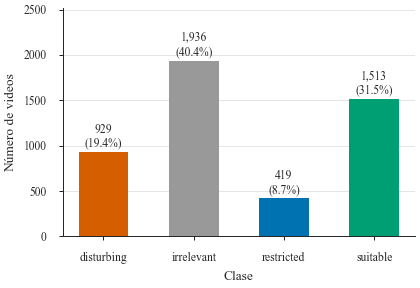

In [5]:
# Visualizar distribución de clases
counts = df_train['classification_label'].value_counts()[ORDEN]
fig, ax = plt.subplots(figsize=(COL, 2.4))

# Gráfico de barras con valores y porcentajes calculados
bars = ax.bar(ORDEN, counts.values, color=[COLORES[c] for c in ORDEN], width=0.55, edgecolor='none', linewidth=0)
total = counts.sum()
for b in bars:
    h = b.get_height()
    pct = (h / total) * 100
    ax.text(b.get_x() + b.get_width()/2., h + 30, f'{int(h):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=7)
ax.set_ylim(0, counts.max() * 1.3)
ax.set_xlabel('Clase')
ax.set_ylabel('Número de videos')
ax.grid(axis='y', color='0.85', linewidth=0.4)
ax.set_axisbelow(True)
sns.despine(ax=ax)

plt.savefig('images_overleaf/distrib_clases_groundtruth.png')
plt.show()

## 3. Primeras Filas del Dataset

In [6]:
print("Primeras filas del dataset de entrenamiento:")
df_train.head()

Primeras filas del dataset de entrenamiento:


## 4. Estadísticas Descriptivas del Dataset de Entrenamiento

In [7]:
# Estadísticas descriptivas de variables numéricas
numeric_cols = ['view_count', 'like_count', 'dislike_count', 'comment_count', 'duration_seconds']
df_train_numeric = df_train[numeric_cols].copy()

print("Estadísticas descriptivas (Dataset de Entrenamiento):")
print(df_train_numeric.describe())

Estadísticas descriptivas (Dataset de Entrenamiento):
            view_count   like_count  dislike_count  comment_count  duration_seconds
count         4,794.00     4,669.00       4,669.00       4,569.00          4,796.00
mean      6,142,716.96    26,878.13       3,718.92       2,378.41            752.06
std      43,836,538.05   155,478.81      25,425.08      12,849.85          1,986.99
min               0.00         0.00           0.00           0.00              0.00
25%           1,140.00        10.00           1.00           1.00            167.00
50%          90,093.50       502.00          53.00          49.00            345.50
75%       1,775,452.75    10,122.00       1,097.00         763.00            706.25
max   1,664,660,083.00 4,392,637.00   1,071,513.00     323,267.00         39,433.00


In [8]:
# Análisis de valores faltantes
print("Valores faltantes por columna (Dataset de Entrenamiento):")
missing_values = df_train.isnull().sum()
missing_percentage = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

Valores faltantes por columna (Dataset de Entrenamiento):
                  Missing Count  Missing Percentage
description                 506               10.55
tags                        883               18.41
duration_iso                  1                0.02
duration_seconds              1                0.02
definition                    1                0.02
caption                       1                0.02
licensed_content              1                0.02
view_count                    3                0.06
like_count                  128                2.67
dislike_count               128                2.67
comment_count               228                4.75
prediction                 4797              100.00


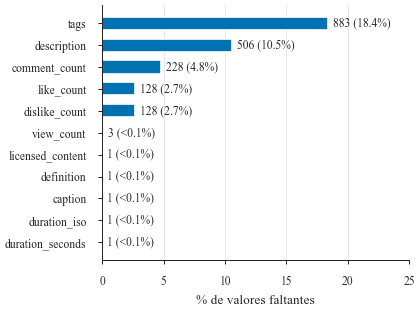

In [9]:
# Visualización de valores faltantes por columna
missing_count = df_train.isnull().sum()
missing_percent = (missing_count / len(df_train)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percent})
# Excluir prediction por estar vacía por diseño
missing_cols = missing_df[(missing_df['Missing Count'] > 0) & (missing_df.index != 'prediction')].sort_values('Missing Count', ascending=True)

fig, ax = plt.subplots(figsize=(COL, 2.6))
bars = ax.barh(missing_cols.index, missing_cols['Missing Percentage'], color='#0072B2', height=0.6)
for i, (idx, row) in enumerate(missing_cols.iterrows()):
    cnt = int(row['Missing Count'])
    pct = row['Missing Percentage']
    pct_str = "<0.1%" if pct < 0.1 else f"{pct:.1f}%"
    ax.text(pct + 0.4, i, f"{cnt} ({pct_str})", va='center', fontsize=7)
ax.set_xlim(0, 25)
ax.set_xticks(range(0, 26, 5))
ax.set_xlabel('% de valores faltantes')
ax.set_ylabel('')
ax.grid(axis='x', color='0.85', linewidth=0.4)
ax.set_axisbelow(True)
sns.despine(ax=ax)

plt.savefig('images_overleaf/valores_faltantes_groundtruth.png')
plt.show()

## 5. Métricas de Engagement por Categoría (Entrenamiento)

In [10]:
# Estadísticas de engagement por categoría
engagement_metrics = ['view_count', 'like_count', 'comment_count']

for metric in engagement_metrics:
    print(f"\n{'='*50}")
    print(f"{metric.upper()} por categoría (Entrenamiento):")
    print(f"{'='*50}")
    
    stats_by_category = df_train.groupby('classification_label')[metric].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    print(stats_by_category)


VIEW_COUNT por categoría (Entrenamiento):
                      count          mean       median           std  min              max
classification_label                                                                      
disturbing              929  3,193,286.59    39,144.00 15,452,148.11 0.00   341,629,926.00
irrelevant             1934  3,486,723.52    10,436.00 29,164,201.75 0.00   699,895,118.00
restricted              419  8,272,591.13 1,348,394.00 21,829,769.40 1.00   194,569,144.00
suitable               1512 10,761,959.60   407,330.00 68,498,396.60 0.00 1,664,660,083.00

LIKE_COUNT por categoría (Entrenamiento):
                      count      mean   median        std  min          max
classification_label                                                       
disturbing              921 18,536.99   202.00  82,705.15 0.00 1,403,940.00
irrelevant             1908 35,003.91    87.00 210,949.86 0.00 4,392,637.00
restricted              415 25,398.39 5,130.00  55,684.65 0.00  

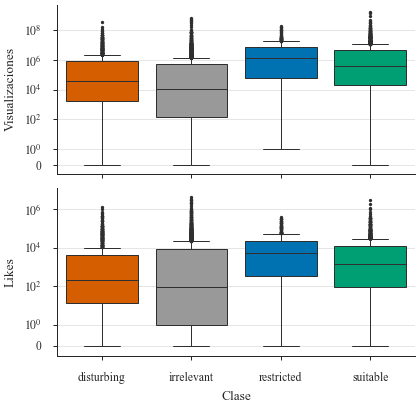

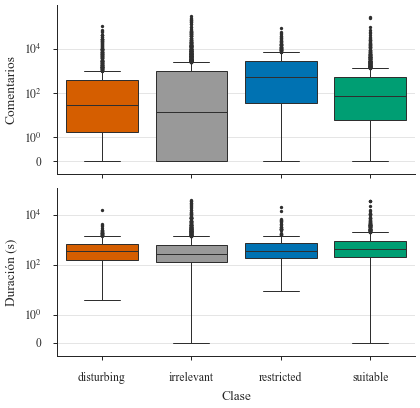

In [11]:
# Visualizar engagement por categoría (dividido en dos figuras de una columna)
from matplotlib.ticker import FixedLocator, FuncFormatter

def format_symlog_tick(val, pos):
    if val == 0:
        return '0'
    logv = int(round(np.log10(val)))
    if logv == 0:
        return '$10^0$'
    return f'$10^{{{logv}}}$'

tick_candidates = [0, 1, 1e2, 1e4, 1e6, 1e8]

# 1. Vistas y Likes
fig, axes = plt.subplots(2, 1, figsize=(COL, 3.4), sharex=True)
panels_a = [('view_count', 'Visualizaciones', axes[0]),
            ('like_count', 'Likes', axes[1])]

for col, ylabel, ax in panels_a:
    sns.boxplot(data=df_train, x='classification_label', y=col, ax=ax,
                order=ORDEN, palette=COLORES, hue='classification_label', legend=False,
                saturation=1, fliersize=1, linewidth=0.6)
    ymax = df_train[col].max()
    ax.set_yscale('symlog', linthresh=1)
    ax.set_ylim(bottom=-0.5, top=ymax * 3)
    ax.set_ylabel(ylabel)
    ticks = [t for t in tick_candidates if -0.5 <= t <= ymax * 3]
    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(format_symlog_tick))
    ax.yaxis.set_minor_locator(FixedLocator([]))
    ax.grid(axis='y', color='0.85', linewidth=0.4)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
axes[1].set_xlabel('Clase')

plt.savefig('images_overleaf/distrib_engagement_vistas_likes_groundtruth.png')
plt.show()

# 2. Comentarios y Duración (s)
fig, axes = plt.subplots(2, 1, figsize=(COL, 3.4), sharex=True)
panels_b = [('comment_count', 'Comentarios', axes[0]),
            ('duration_seconds', 'Duración (s)', axes[1])]

for col, ylabel, ax in panels_b:
    sns.boxplot(data=df_train, x='classification_label', y=col, ax=ax,
                order=ORDEN, palette=COLORES, hue='classification_label', legend=False,
                saturation=1, fliersize=1, linewidth=0.6)
    ymax = df_train[col].max()
    ax.set_yscale('symlog', linthresh=1)
    ax.set_ylim(bottom=-0.5, top=ymax * 3)
    ax.set_ylabel(ylabel)
    ticks = [t for t in tick_candidates if -0.5 <= t <= ymax * 3]
    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(format_symlog_tick))
    ax.yaxis.set_minor_locator(FixedLocator([]))
    ax.grid(axis='y', color='0.85', linewidth=0.4)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
axes[1].set_xlabel('Clase')

plt.savefig('images_overleaf/distrib_engagement_comentarios_duracion_groundtruth.png')
plt.show()

In [12]:
# Verificación de ceros en métricas de engagement (no visibles en escala logarítmica)
zeros_engagement = {
    'Visualizaciones (view_count = 0)': (df_train['view_count'] == 0).sum(),
    'Likes (like_count = 0)': (df_train['like_count'] == 0).sum(),
    'Comentarios (comment_count = 0)': (df_train['comment_count'] == 0).sum(),
    'Duración (duration_seconds = 0)': (df_train['duration_seconds'] == 0).sum()
}
print("Videos con valor cero por métrica (no graficados en escala log):")
for metrica, cnt in zeros_engagement.items():
    print(f" - {metrica}: {cnt}")

Videos con valor cero por métrica (no graficados en escala log):
 - Visualizaciones (view_count = 0): 11
 - Likes (like_count = 0): 468
 - Comentarios (comment_count = 0): 996
 - Duración (duration_seconds = 0): 10


## 6. Categorías de YouTube (Entrenamiento)

In [13]:
# Distribución de category_id
category_dist = df_train['category_id'].value_counts().head(15)
print("Top 15 categorías de YouTube (Dataset de Entrenamiento):")
print(category_dist)

Top 15 categorías de YouTube (Dataset de Entrenamiento):
category_id
24    1223
22    1088
1      815
20     365
27     291
10     266
23     220
26     114
25     106
17      97
2       55
28      53
19      39
15      29
29      25
Name: count, dtype: int64


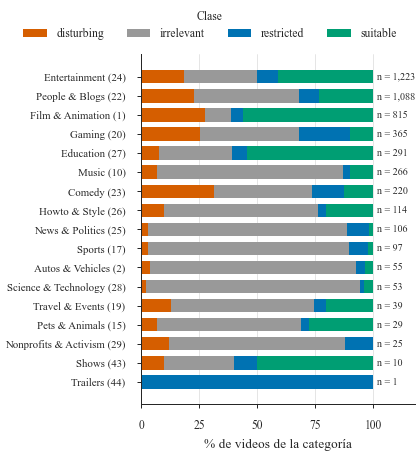

In [14]:
# Visualizar categorías por etiqueta de clasificación (barras horizontales apiladas al 100%)
CATEGORIAS_YT = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals',
    17: 'Sports', 19: 'Travel & Events', 20: 'Gaming', 22: 'People & Blogs',
    23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style',
    27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism',
    43: 'Shows', 44: 'Trailers'
}

cat = pd.crosstab(df_train['category_id'], df_train['classification_label'])[ORDEN]
cat = cat.loc[cat.sum(axis=1).sort_values(ascending=True).index]
pct = cat.div(cat.sum(axis=1), axis=0) * 100
totals = cat.sum(axis=1)
cat_labels = [f"{CATEGORIAS_YT.get(c, f'ID {c}')} ({c})" for c in cat.index]

fig, ax = plt.subplots(figsize=(COL, 3.8))
izq = np.zeros(len(pct))
for clase in ORDEN:
    ax.barh(range(len(pct)), pct[clase].values, left=izq, height=0.7, color=COLORES[clase], label=clase, edgecolor='none')
    izq += pct[clase].values

for i, total_n in enumerate(totals):
    ax.text(101.5, i, f"n = {total_n:,}", va='center', ha='left', fontsize=6)

ax.set_yticks(range(len(cat_labels)))
ax.set_yticklabels(cat_labels, fontsize=6.5)
ax.set_xlim(0, 118)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('% de videos de la categoría')
ax.grid(axis='x', color='0.85', linewidth=0.4)
ax.set_axisbelow(True)
sns.despine(ax=ax)

fig.legend(loc='outside upper center', ncol=4, frameon=False, title='Clase', title_fontsize=7)

plt.savefig('images_overleaf/distrib_categ_etiqueta_groundtruth.png')
plt.show()

In [15]:
# Tabla de las 17 categorías de YouTube presentes en el dataset ordenadas por frecuencia
CATEGORIAS_YT = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals',
    17: 'Sports', 19: 'Travel & Events', 20: 'Gaming', 22: 'People & Blogs',
    23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style',
    27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism',
    43: 'Shows', 44: 'Trailers'
}

cat_counts = df_train['category_id'].value_counts()
cat_table = pd.DataFrame({
    'ID': cat_counts.index,
    'Nombre': [CATEGORIAS_YT.get(cid, f'ID {cid}') for cid in cat_counts.index],
    'Número de videos': cat_counts.values
})
print("Distribución de las 17 categorías de YouTube (Dataset de Entrenamiento):")
print(cat_table.to_string(index=False))

Distribución de las 17 categorías de YouTube (Dataset de Entrenamiento):
 ID                Nombre  Número de videos
 24         Entertainment              1223
 22        People & Blogs              1088
  1      Film & Animation               815
 20                Gaming               365
 27             Education               291
 10                 Music               266
 23                Comedy               220
 26         Howto & Style               114
 25       News & Politics               106
 17                Sports                97
  2      Autos & Vehicles                55
 28  Science & Technology                53
 19       Travel & Events                39
 15        Pets & Animals                29
 29 Nonprofits & Activism                25
 43                 Shows                10
 44              Trailers                 1


## 7. Duración de Videos (Entrenamiento)

In [16]:
# Duración por categoría (ya está en segundos en el CSV)
duration_by_category = df_train.groupby('classification_label')['duration_seconds'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print("Duración por categoría (segundos) - Dataset de Entrenamiento:")
print(duration_by_category)

Duración por categoría (segundos) - Dataset de Entrenamiento:
                      count   mean  median      std  min       max
classification_label                                              
disturbing              929 508.71  359.00   656.71 4.00 14,959.00
irrelevant             1936 785.71  264.00 2,401.49 0.00 39,433.00
restricted              419 703.29  350.00 1,471.53 9.00 20,826.00
suitable               1512 872.00  443.50 2,055.90 0.00 36,524.00


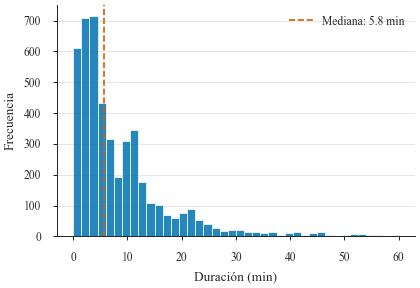

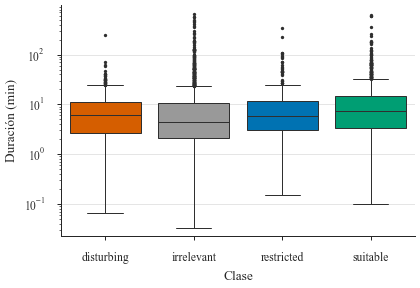

In [17]:
# Visualizar distribución de duración (dividido en histograma y boxplot de una columna)
df_train['duration_minutes'] = df_train['duration_seconds'] / 60
dur_min = df_train['duration_minutes'].dropna()

# 1. Histograma general (0 a 60 min)
fig, ax = plt.subplots(figsize=(COL, 2.4))
ax.hist(dur_min, bins=40, range=(0, 60),
        color='#0072B2', edgecolor='white', linewidth=0.5, alpha=0.85)
med_dur = dur_min.median()
ax.axvline(med_dur, color='#D55E00', linestyle='--', linewidth=1.0,
           label=f'Mediana: {med_dur:.1f} min')
ax.set_xlabel('Duración (min)')
ax.set_ylabel('Frecuencia')
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', color='0.85', linewidth=0.4)
ax.set_axisbelow(True)
sns.despine(ax=ax)

plt.savefig('images_overleaf/distrib_duracion_hist_groundtruth.png')
plt.show()

# 2. Boxplot por clase en escala log (solo videos con duración > 0)
dur_pos = df_train[df_train['duration_seconds'] > 0].copy()
fig, ax = plt.subplots(figsize=(COL, 2.4))
sns.boxplot(data=dur_pos, x='classification_label', y='duration_minutes', ax=ax,
            order=ORDEN, palette=COLORES, hue='classification_label', legend=False,
            saturation=1, fliersize=1, linewidth=0.6)
ax.set_yscale('log')
ax.set_ylim(bottom=dur_pos['duration_minutes'].min() / 1.5,
            top=dur_pos['duration_minutes'].max() * 1.5)
ax.set_xlabel('Clase')
ax.set_ylabel('Duración (min)')
ax.grid(axis='y', color='0.85', linewidth=0.4)
ax.set_axisbelow(True)
sns.despine(ax=ax)

plt.savefig('images_overleaf/distrib_duracion_box_groundtruth.png')
plt.show()

In [18]:
# Verificación de videos fuera de los límites visuales de los gráficos de duración
dur_min = df_train['duration_seconds'] / 60
gt_60_cnt = (dur_min > 60).sum()
gt_45_cnt = (dur_min > 45).sum()
eq_0_cnt = (df_train['duration_seconds'] == 0).sum()

print(f"Videos con duración > 60 min (no mostrados en histograma 0-60 min): {gt_60_cnt}")
print(f"Videos con duración > 45 min (no mostrados en boxplot limitado a 45 min): {gt_45_cnt}")
print(f"Videos con duración = 0 s (no visibles en escala log): {eq_0_cnt}")

Videos con duración > 60 min (no mostrados en histograma 0-60 min): 135
Videos con duración > 45 min (no mostrados en boxplot limitado a 45 min): 192
Videos con duración = 0 s (no visibles en escala log): 10


## 8. Calidad de Video (Entrenamiento)

In [19]:
# Distribución de definición de video
definition_dist = df_train['definition'].value_counts()
print("Distribución de definición de video (Dataset de Entrenamiento):")
print(definition_dist)

Distribución de definición de video (Dataset de Entrenamiento):
definition
hd    3748
sd    1048
Name: count, dtype: int64


In [20]:
# Definición por categoría y prueba de asociación (Chi-cuadrado y V de Cramér)
from scipy.stats import chi2_contingency

definition_by_category = pd.crosstab(df_train['definition'], df_train['classification_label'])
print("Definición por categoría:")
print(definition_by_category)

chi2, p_val, dof, ex = chi2_contingency(definition_by_category)
n = definition_by_category.sum().sum()
min_dim = min(definition_by_category.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))

print(f"\nPrueba de Chi-cuadrado: chi2 = {chi2:.4f}, p-value = {p_val:.4e}")
print(f"V de Cramér = {cramer_v:.4f} (asociación estadísticamente significativa pero muy débil)")


Definición por categoría:
classification_label  disturbing  irrelevant  restricted  suitable
definition                                                        
hd                           771        1456         326      1195
sd                           158         480          93       317

Prueba de Chi-cuadrado: chi2 = 23.3007, p-value = 3.4954e-05
V de Cramér = 0.0697 (asociación estadísticamente significativa pero muy débil)


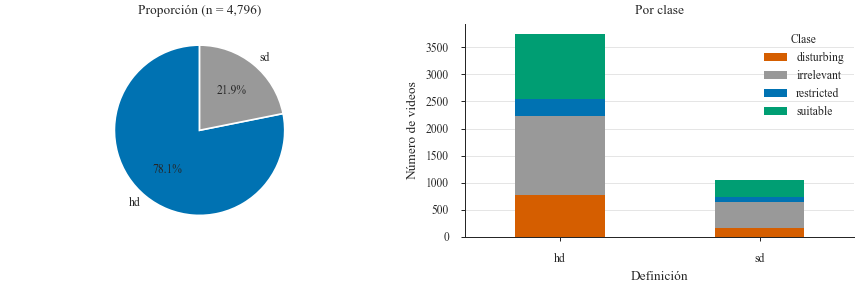

In [21]:
# Visualizar definición por categoría
def_counts = df_train['definition'].dropna().value_counts()
def_by_cat = pd.crosstab(df_train['definition'], df_train['classification_label'])[ORDEN]
n_def = len(df_train['definition'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(DOBLE, 2.4))
apply_layout_g3(fig)

axes[0].pie(def_counts.values, labels=def_counts.index, autopct='%1.1f%%',
            colors=['#0072B2', '#999999'], startangle=90, textprops={'fontsize': 7})
axes[0].set_title(f'Proporción (n = {n_def:,})')

def_by_cat.plot(kind='bar', stacked=True, ax=axes[1],
                color=[COLORES[c] for c in ORDEN], edgecolor='none', width=0.45)
axes[1].set_xlabel('Definición')
axes[1].set_ylabel('Número de videos')
axes[1].set_title('Por clase')
axes[1].legend(title='Clase', title_fontsize=7, frameon=False)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', color='0.85', linewidth=0.4)
axes[1].set_axisbelow(True)
sns.despine(ax=axes[1])

plt.savefig('images_overleaf/distrib_definicion_groundtruth.png')
plt.show()

## 9. Análisis de Tags (Entrenamiento)

### Metodología y Corrección de Extracción de Tags:
En los metadatos de YouTube, las etiquetas no se almacenan como registros independientes, sino concatenadas en una sola cadena de texto delimitada por plecas (`|`).

- **Extracción Individual:** En lugar de contabilizar la cadena completa (lo que medía listas idénticas de tags repetidas entre videos), se separan las etiquetas mediante `.split('|')`, limpiando espacios en blanco y descartando cadenas vacías. Esto permite analizar la frecuencia real de cada tag como unidad independiente.
- **Normalización a Minúsculas (Case-Folding):** Se convierten todas las etiquetas a minúsculas para unificar variantes ortográficas que representan el mismo concepto (por ejemplo, consolidando `cartoon` y `Cartoon`, o `animation` y `Animation`). Esta normalización es el estándar previo para la vectorización de texto (TF-IDF) en la Etapa 2.
- **Cruce con Clasificación:** Se evalúa la distribución de cada tag respecto a la variable objetivo (`classification_label`), identificando qué etiquetas se asocian predominantemente a contenido apto (`suitable`) y cuáles actúan como señal de contenido perturbador (`disturbing`).


In [22]:
# Extraer todos los tags individuales (separados por '|' en YouTube)
# 1. Conteo crudo vs. limpio de tags individuales
raw_tags = df_train['tags'].dropna().astype(str).str.split('|').explode()
print(f"Total de tags únicos crudos (sin limpiar espacios ni vacíos): {raw_tags.nunique():,}")
print(f"Total de asignaciones crudas: {len(raw_tags):,}")

all_tags_clean = []
for tags in df_train['tags'].dropna():
    if isinstance(tags, str):
        parsed = [t.strip() for t in tags.split('|') if t.strip()]
        all_tags_clean.extend(parsed)

v_with_tags = df_train['tags'].notna().sum()
v_no_tags = df_train['tags'].isna().sum() + (df_train['tags'] == '').sum()
print(f"\nVideos con tags: {v_with_tags} ({v_no_tags} videos sin tags, {v_no_tags/len(df_train)*100:.1f}%)")
print(f"Listas de tags distintas: {df_train['tags'].dropna().nunique()}")
print(f"Total de tags individuales únicos (limpios): {len(set(all_tags_clean)):,}")
print(f"Total de asignaciones de tags (limpias): {len(all_tags_clean):,} (promedio: {len(all_tags_clean)/v_with_tags:.1f} tags/video)")

# 2. Tags normalizados a minúsculas (case-folding para NLP)
all_tags_lower = [t.lower() for t in all_tags_clean]
print(f"Total de tags únicos normalizados a minúsculas: {len(set(all_tags_lower)):,}")


Total de tags únicos crudos (sin limpiar espacios ni vacíos): 40,105
Total de asignaciones crudas: 73,641

Videos con tags: 3914 (883 videos sin tags, 18.4%)
Listas de tags distintas: 3705
Total de tags individuales únicos (limpios): 40,096
Total de asignaciones de tags (limpias): 73,640 (promedio: 18.8 tags/video)
Total de tags únicos normalizados a minúsculas: 36,750


In [23]:
# Top 20 tags individuales más frecuentes (normalizados a minúsculas) y distribución por clase
tag_rows = []
for idx, row in df_train.dropna(subset=['tags']).iterrows():
    tags = list(dict.fromkeys([t.strip().lower() for t in str(row['tags']).split('|') if t.strip()]))
    for t in tags:
        tag_rows.append({
            'video_id': row['video_id'],
            'channel_id': row['channel_id'],
            'classification_label': row['classification_label'],
            'tag': t
        })
df_tags_long = pd.DataFrame(tag_rows)

top20_tags = df_tags_long['tag'].value_counts().head(20)
ct_tags = pd.crosstab(df_tags_long['tag'], df_tags_long['classification_label']).loc[top20_tags.index]
ct_tags_pct = (ct_tags.div(ct_tags.sum(axis=1), axis=0) * 100).round(1)

tags_summary_df = pd.DataFrame({
    'Tag': top20_tags.index,
    'Frecuencia': top20_tags.values,
    '% Disturbing': ct_tags_pct['disturbing'].values,
    '% Irrelevant': ct_tags_pct['irrelevant'].values,
    '% Restricted': ct_tags_pct['restricted'].values,
    '% Suitable': ct_tags_pct['suitable'].values
})
print("Top 20 tags individuales más frecuentes (normalizados a minúsculas) y distribución por clase:")
print(tags_summary_df.to_string(index=False))


Top 20 tags individuales más frecuentes (normalizados a minúsculas) y distribución por clase:
           Tag  Frecuencia  % Disturbing  % Irrelevant  % Restricted  % Suitable
          kids         412         31.10          4.60          1.20       63.10
         funny         400         39.50         19.00          6.50       35.00
     animation         347         32.90          4.30          0.90       62.00
       cartoon         299         24.70          2.70          0.30       72.20
           fun         252         32.50          7.90          4.00       55.60
          toys         221         24.90          4.50          0.50       70.10
      children         215         20.90          7.90          0.00       71.20
     spiderman         209         74.60          4.30          1.90       19.10
          elsa         200         60.00          6.00          3.00       31.00
        disney         195         30.80          5.60          1.00       62.60
        frozen 

In [24]:
# Verificación de reproducibilidad: análisis de canales por tag y conteo total deduplicado
print("Total de asignaciones deduplicadas por video (filas en df_tags_long):", len(df_tags_long))
print("\nConcentración de canal en tags clave:")
for t in ['spiderman', 'elsa', 'frozen', 'superhero', 'kids', 'children']:
    x = df_tags_long[df_tags_long['tag'] == t]
    vc = x['channel_id'].value_counts()
    pct_top = round(vc.iloc[0] / len(x) * 100, 1)
    print(f"{t:12s} | Videos: {len(x):3d} | Canales únicos: {x['channel_id'].nunique():3d} | Top canal: {vc.index[0]} ({pct_top}%)")


Total de asignaciones deduplicadas por video (filas en df_tags_long): 73084

Concentración de canal en tags clave:
spiderman    | Videos: 209 | Canales únicos: 181 | Top canal: UC_W0_Nv-3rxpWVvosddhrPw (3.8%)
elsa         | Videos: 200 | Canales únicos: 171 | Top canal: UCQ00zWTLrgRQJUb8MHQg21A (2.5%)
frozen       | Videos: 194 | Canales únicos: 169 | Top canal: UCQ00zWTLrgRQJUb8MHQg21A (2.6%)
superhero    | Videos: 156 | Canales únicos: 133 | Top canal: UC_W0_Nv-3rxpWVvosddhrPw (3.8%)
kids         | Videos: 412 | Canales únicos: 270 | Top canal: UC9-oOzriEPfpPvjTOAu3Cww (7.3%)
children     | Videos: 215 | Canales únicos: 129 | Top canal: UC9-oOzriEPfpPvjTOAu3Cww (14.4%)


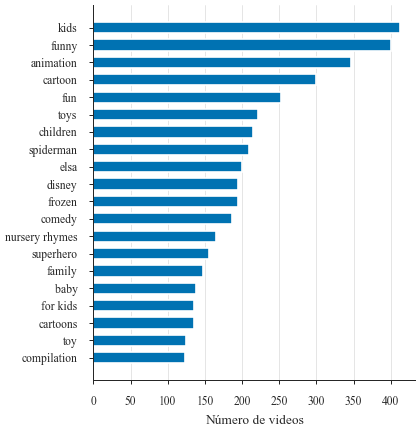

In [25]:
# Visualizar top 20 tags individuales más frecuentes
fig, ax = plt.subplots(figsize=(COL, 3.6))
ax.barh(range(len(top20_tags)), top20_tags.values[::-1], color='#0072B2', height=0.65)
ax.set_yticks(range(len(top20_tags)))
ax.set_yticklabels(top20_tags.index[::-1], fontsize=7)
ax.set_xlabel('Número de videos')
ax.set_ylabel('')
ax.grid(axis='x', color='0.85', linewidth=0.4)
ax.set_axisbelow(True)
sns.despine(ax=ax)

plt.savefig('images_overleaf/tags_frecuentes_groundtruth.png')
plt.show()

## 10. Análisis de Títulos (Entrenamiento)

In [26]:
# Longitud de títulos
df_train['title_length'] = df_train['title'].str.len()
df_train['title_word_count'] = df_train['title'].str.split().str.len()

print("Estadísticas de longitud de títulos (Dataset de Entrenamiento):")
print(df_train[['title_length', 'title_word_count']].describe())

Estadísticas de longitud de títulos (Dataset de Entrenamiento):
       title_length  title_word_count
count      4,797.00          4,797.00
mean          53.74              9.34
std           24.92              4.37
min            1.00              1.00
25%           34.00              6.00
50%           51.00              9.00
75%           73.00             13.00
max          113.00             22.00


In [27]:
# Longitud de título por categoría
title_stats_by_category = df_train.groupby('classification_label')[['title_length', 'title_word_count']].agg([
    'mean', 'median', 'std']).round(2)
print("Estadísticas de títulos por categoría (Dataset de Entrenamiento):")
print(title_stats_by_category)

Estadísticas de títulos por categoría (Dataset de Entrenamiento):
                     title_length              title_word_count            
                             mean median   std             mean median  std
classification_label                                                       
disturbing                  58.98  56.00 28.18            10.04  10.00 4.55
irrelevant                  46.80  43.50 22.82             8.12   8.00 4.17
restricted                  44.79  42.00 20.88             7.79   7.00 3.70
suitable                    61.88  61.00 22.98            10.91  11.00 4.05


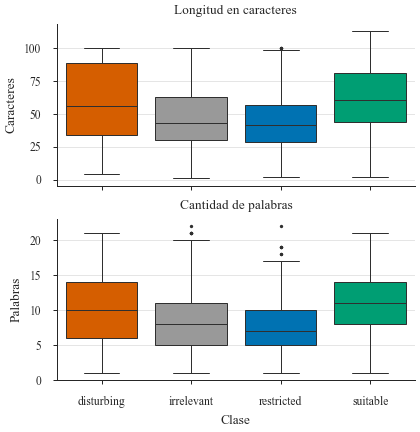

In [28]:
# Visualizar longitud de títulos (dos boxplots apilados con eje X compartido)
fig, axes = plt.subplots(2, 1, figsize=(COL, 3.6), sharex=True)

sns.boxplot(data=df_train, x='classification_label', y='title_length', ax=axes[0],
            order=ORDEN, palette=COLORES, hue='classification_label', legend=False,
            saturation=1, fliersize=1, linewidth=0.6)
axes[0].set_ylabel('Caracteres')
axes[0].set_title('Longitud en caracteres')
axes[0].grid(axis='y', color='0.85', linewidth=0.4)
axes[0].set_axisbelow(True)
sns.despine(ax=axes[0])

sns.boxplot(data=df_train, x='classification_label', y='title_word_count', ax=axes[1],
            order=ORDEN, palette=COLORES, hue='classification_label', legend=False,
            saturation=1, fliersize=1, linewidth=0.6)
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Palabras')
axes[1].set_title('Cantidad de palabras')
axes[1].grid(axis='y', color='0.85', linewidth=0.4)
axes[1].set_axisbelow(True)
sns.despine(ax=axes[1])

plt.savefig('images_overleaf/distrib_titulo_groundtruth.png')
plt.show()

## 11. Resumen del Dataset de Entrenamiento

In [29]:
# Resumen estadístico general del dataset de entrenamiento
print("="*60)
print("RESUMEN DEL DATASET DE ENTRENAMIENTO (GROUNDTRUTH)")
print("="*60)

print(f"\nTotal de videos de entrenamiento: {len(df_train):,}")
print(f"\nDistribución de clases:")
for label, count in label_counts.items():
    print(f"  - {label}: {count:,} ({count/len(df_train)*100:.1f}%)")

print(f"\nEstadísticas de engagement:")
print(f"  - Vistas totales: {df_train['view_count'].sum():,}")
print(f"  - Promedio de vistas: {df_train['view_count'].mean():,.0f}")
print(f"  - Promedio de likes: {df_train['like_count'].mean():,.0f}")
print(f"  - Promedio de comentarios: {df_train['comment_count'].mean():,.0f}")
print(f"  - Videos con 0 vistas: {(df_train['view_count'] == 0).sum()} | Con duración 0s: {(df_train['duration_seconds'] == 0).sum()}")

print(f"\nEstadísticas de contenido:")
print(f"  - Duración promedio: {df_train['duration_minutes'].mean():.1f} minutos")
print(f"  - Duración mediana: {df_train['duration_minutes'].median():.1f} minutos")
print(f"  - Longitud promedio de título: {df_train['title_length'].mean():.1f} caracteres")
print(f"  - Número promedio de palabras en título: {df_train['title_word_count'].mean():.1f}")

print(f"\nCalidad de video:")
for definition, count in definition_dist.items():
    print(f"  - {definition}: {count} ({count/len(df_train)*100:.1f}%)")

print(f"\nDiversidad de contenido:")
print(f"  - Categorías de YouTube únicas: {df_train['category_id'].nunique()}")
print(f"  - Canales únicos: {df_train['channel_id'].nunique()} (por ID) / {df_train['channel_title'].nunique()} (por título)")
print(f"  - Tags individuales únicos: {len(set(all_tags_clean)):,} (limpios) / {len(set(all_tags_lower)):,} (normalizados minúsculas)")

print(f"\nUSO DEL DATASET:")
print(f" • Este dataset (dataset_groundtruth.csv) se usará para ENTRENAR el modelo")
print(f" • Tiene etiquetas 100% confiables (anotaciones manuales humanas)")
print(f" • Los otros datasets se usarán para comprobación de consistencia y predicciones con el modelo entrenado")


RESUMEN DEL DATASET DE ENTRENAMIENTO (GROUNDTRUTH)

Total de videos de entrenamiento: 4,797

Distribución de clases:
  - irrelevant: 1,936 (40.4%)
  - suitable: 1,513 (31.5%)
  - disturbing: 929 (19.4%)
  - restricted: 419 (8.7%)

Estadísticas de engagement:
  - Vistas totales: 29,448,185,127.0
  - Promedio de vistas: 6,142,717
  - Promedio de likes: 26,878
  - Promedio de comentarios: 2,378
  - Videos con 0 vistas: 11 | Con duración 0s: 10

Estadísticas de contenido:
  - Duración promedio: 12.5 minutos
  - Duración mediana: 5.8 minutos
  - Longitud promedio de título: 53.7 caracteres
  - Número promedio de palabras en título: 9.3

Calidad de video:
  - hd: 3748 (78.1%)
  - sd: 1048 (21.8%)

Diversidad de contenido:
  - Categorías de YouTube únicas: 17
  - Canales únicos: 3818 (por ID) / 3811 (por título)
  - Tags individuales únicos: 40,096 (limpios) / 36,750 (normalizados minúsculas)

USO DEL DATASET:
 • Este dataset (dataset_groundtruth.csv) se usará para ENTRENAR el modelo
 • Tiene

## 12. Detección de Outliers (Dataset de Entrenamiento)

### Metodología: detección de outliers con el rango intercuartílico (IQR)

Para esta sección implementamos el método del **rango intercuartílico (IQR)** para identificar valores atípicos (*outliers*) en las cinco variables numéricas del dataset.

Este método se basa en ordenar las observaciones y ubicar el 50% central de los datos, que queda delimitado entre el percentil 25 ($Q_1$) y el percentil 75 ($Q_3$). La distancia entre estos dos cuartiles se conoce como $IQR = Q_3 - Q_1$.

La regla es: todo valor que quede a más de 1.5 veces el IQR por encima de $Q_3$ o por debajo de $Q_1$ se etiqueta como outlier. Es una convención estadística ampliamente usada, no una ley matemática exacta.

Ejecutamos este análisis dos veces —sobre la escala original y sobre una transformación logarítmica (`log1p`)— porque las métricas de engagement de YouTube (vistas, likes, dislikes, comentarios) tienen una asimetría muy fuerte hacia la derecha: la mayoría de los videos tiene pocas interacciones, mientras que un puñado de videos virales concentra cifras muy por encima del resto. En escala original, esa asimetría hace que el IQR marque como "outlier" a casi cualquier video con desempeño por encima del promedio, aunque sea un comportamiento normal de la plataforma. Al aplicar `log1p` antes de calcular el IQR, comprimimos los órdenes de magnitud grandes y expandimos los valores pequeños, lo que permite distinguir si una observación es realmente atípica o si solo parecía serlo por la escala.

In [30]:
# Detección de outliers mediante el método IQR (rango intercuartílico)
def detectar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return len(outliers), (len(outliers) / serie.notna().sum()) * 100, lim_inf, lim_sup

print("DETECCIÓN DE OUTLIERS - MÉTODO IQR (escala original)")
print("="*70)

resultados_outliers = []
for col in numeric_cols:
    serie = df_train[col].dropna()
    n_out, pct_out, lim_inf, lim_sup = detectar_outliers_iqr(serie)
    resultados_outliers.append({
        'Variable': col,
        'N° Outliers': n_out,
        '% Outliers': round(pct_out, 2),
        'Límite inferior': round(lim_inf, 2),
        'Límite superior': round(lim_sup, 2)
    })

df_outliers = pd.DataFrame(resultados_outliers)
print(df_outliers.to_string(index=False))

DETECCIÓN DE OUTLIERS - MÉTODO IQR (escala original)
        Variable  N° Outliers  % Outliers  Límite inferior  Límite superior
      view_count          802       16.73    -2,660,329.12     4,436,921.88
      like_count          730       15.64       -15,158.00        25,290.00
   dislike_count          791       16.94        -1,643.00         2,741.00
   comment_count          721       15.78        -1,142.00         1,906.00
duration_seconds          385        8.03          -641.88         1,515.12


In [31]:
# Desglose de outliers por clase para view_count y like_count (método IQR)
orden_clases = ['disturbing', 'irrelevant', 'restricted', 'suitable']
for col in ['view_count', 'like_count']:
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1
    outliers_mask = (df_train[col] < (q1 - 1.5 * iqr)) | (df_train[col] > (q3 + 1.5 * iqr))
    outliers_by_class = df_train[outliers_mask]['classification_label'].value_counts()
    outliers_by_class = outliers_by_class.reindex(orden_clases).dropna()
    total_outliers = outliers_mask.sum()
    print(f"Outliers en {col} (IQR original, total = {total_outliers}):")
    for clase, cnt in outliers_by_class.items():
        pct_clase = (cnt / total_outliers) * 100
        print(f"  - {clase}: {int(cnt)} ({pct_clase:.1f}%)")
    print()

Outliers en view_count (IQR original, total = 802):
  - disturbing: 116 (14.5%)
  - irrelevant: 175 (21.8%)
  - restricted: 132 (16.5%)
  - suitable: 379 (47.3%)

Outliers en like_count (IQR original, total = 730):
  - disturbing: 121 (16.6%)
  - irrelevant: 300 (41.1%)
  - restricted: 95 (13.0%)
  - suitable: 214 (29.3%)



In [32]:
# Repetimos el análisis sobre variables transformadas con log1p,
# más apropiado dado el fuerte sesgo positivo de estas métricas
print("DETECCIÓN DE OUTLIERS - MÉTODO IQR (escala log1p)")
print("="*70)

resultados_outliers_log = []
for col in numeric_cols:
    serie_log = np.log1p(df_train[col].dropna())
    n_out, pct_out, lim_inf, lim_sup = detectar_outliers_iqr(serie_log)
    resultados_outliers_log.append({
        'Variable': f'log({col})',
        'N° Outliers': n_out,
        '% Outliers': round(pct_out, 2),
        'Límite inferior (log)': round(lim_inf, 2),
        'Límite superior (log)': round(lim_sup, 2)
    })

df_outliers_log = pd.DataFrame(resultados_outliers_log)
print(df_outliers_log.to_string(index=False))

DETECCIÓN DE OUTLIERS - MÉTODO IQR (escala log1p)
             Variable  N° Outliers  % Outliers  Límite inferior (log)  Límite superior (log)
      log(view_count)            0        0.00                  -3.99                  25.41
      log(like_count)            0        0.00                  -7.84                  19.46
   log(dislike_count)            0        0.00                  -8.77                  16.46
   log(comment_count)            0        0.00                  -8.22                  15.56
log(duration_seconds)          173        3.61                   2.97                   8.72


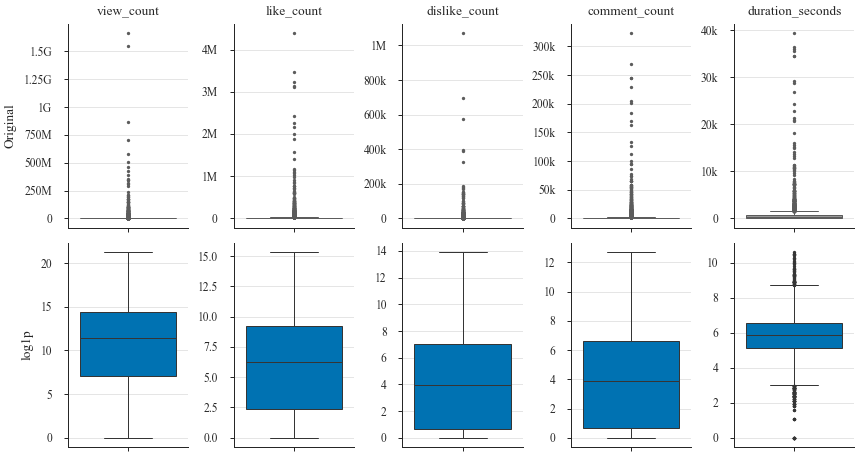

In [33]:
# Visualizar outliers: boxplots en escala original vs. escala log1p
from matplotlib.ticker import EngFormatter

numeric_cols = ['view_count', 'like_count', 'dislike_count', 'comment_count', 'duration_seconds']
fig, axes = plt.subplots(2, 5, figsize=(DOBLE, 3.8))
apply_layout_g3(fig)

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_train[col], ax=axes[0, i], color='#999999', saturation=1, fliersize=1, linewidth=0.6)
    axes[0, i].set_title(col, fontsize=8)
    axes[0, i].set_ylabel('Original' if i == 0 else '')
    axes[0, i].set_xlabel('')
    axes[0, i].yaxis.set_major_formatter(EngFormatter(sep=''))
    axes[0, i].yaxis.get_offset_text().set_visible(False)
    axes[0, i].grid(axis='y', color='0.85', linewidth=0.4)
    axes[0, i].set_axisbelow(True)
    sns.despine(ax=axes[0, i])

    sns.boxplot(y=np.log1p(df_train[col]), ax=axes[1, i], color='#0072B2', saturation=1, fliersize=1, linewidth=0.6)
    axes[1, i].set_title('')
    axes[1, i].set_ylabel('log1p' if i == 0 else '')
    axes[1, i].set_xlabel('')
    axes[1, i].grid(axis='y', color='0.85', linewidth=0.4)
    axes[1, i].set_axisbelow(True)
    sns.despine(ax=axes[1, i])

plt.savefig('images_overleaf/outliers_boxplots_groundtruth.png')
plt.show()

**Interpretación de resultados:**

Al ejecutar el análisis en escala original encontramos que entre el 8% y el 17% de las observaciones quedan fuera de los límites de IQR en cada variable: view_count (802 outliers, 16.7%), like_count (730, 15.6%), dislike_count (791, 16.9%), comment_count (721, 15.8%) y duration_seconds (385, 8.0%). Este porcentaje elevado no representa errores en los datos, sino el efecto esperado de la asimetría fuerte que describimos arriba.

Al repetir el análisis en escala `log1p`, los outliers en view_count, like_count, dislike_count y comment_count caen a 0%. Esto confirma que la transformación logarítmica corrige correctamente la asimetría: los valores "extremos" en escala original eran parte del comportamiento normal de la distribución (videos virales), no anomalías genuinas.

duration_seconds, en cambio, mantiene 173 outliers (3.6%) incluso en escala log. A diferencia de las variables de engagement, esta sí es una señal de duraciones genuinamente atípicas (streams muy largos o clips muy cortos) que vale la pena inspeccionar antes de la Etapa 2, en vez de un artefacto de la escala.

Para validar que el análisis está bien calibrado, revisamos manualmente los videos con mayor view_count (`df_train.nlargest(10, 'view_count')`) y confirmamos que corresponden a contenido viral real, no a errores de carga de datos.

## 13. Cuantificación Adicional del Desbalance de Clases

Complementando la distribución de clases de la Sección 2, se calcula el **ratio de desbalance (IR)** de cada clase respecto a la clase mayoritaria. Esta métrica es estándar para decidir la estrategia de balanceo (class weights, sobremuestreo, submuestreo) que se aplicará en la Etapa 2.

In [34]:
print("RATIO DE DESBALANCE (IR) RESPECTO A LA CLASE MAYORITARIA")
print("="*60)

clase_mayoritaria = label_counts.idxmax()
n_mayoritaria = label_counts.max()

for label, count in label_counts.items():
    ir = n_mayoritaria / count
    print(f"  {label:12s}: {count:,} videos  |  IR = {ir:.2f}x respecto a '{clase_mayoritaria}'")

RATIO DE DESBALANCE (IR) RESPECTO A LA CLASE MAYORITARIA
  irrelevant  : 1,936 videos  |  IR = 1.00x respecto a 'irrelevant'
  suitable    : 1,513 videos  |  IR = 1.28x respecto a 'irrelevant'
  disturbing  : 929 videos  |  IR = 2.08x respecto a 'irrelevant'
  restricted  : 419 videos  |  IR = 4.62x respecto a 'irrelevant'


**Interpretación de resultados:**

El ratio de desbalance (IR) indica cuántas veces más grande es la clase mayoritaria respecto a cada una de las demás. Con un IR de 4.62x, la clase `restricted` es la que presenta el desbalance más severo: por cada video `restricted` en el dataset hay 4.6 videos `irrelevant`. Esto la convierte en la clase que más atención requerirá durante el balanceo (class weights o sobremuestreo) en la Etapa 2, ya que el modelo tendrá muchos menos ejemplos de los que aprender para esta categoría.

## 14. Relaciones entre Variables (Análisis de Correlación)

### Metodología: correlación y prueba de significancia entre grupos

Para esta sección calculamos la correlación entre las variables numéricas, que mide qué tanto dos variables suben y bajan juntas, en una escala de -1 (relación inversa perfecta) a 1 (relación directa perfecta).

Calculamos tres versiones para poder comparar: Pearson en escala original, Pearson en escala `log1p` y Spearman (por rangos). Pearson mide relación lineal pero es sensible a outliers y a la escala de los datos; Spearman mide relación por orden y es más robusto frente a valores extremos. Comparar las tres versiones permite distinguir si una correlación observada es real o si es solo un efecto de la asimetría de los datos.

Además, aplicamos la prueba de **Kruskal-Wallis** para evaluar si la distribución de cada variable numérica difiere de forma significativa entre las cuatro clases (`classification_label`). Usamos esta prueba en lugar de un ANOVA tradicional porque no asume que los datos sigan una distribución normal, algo que claramente no se cumple aquí dado el sesgo fuerte de las variables.

In [35]:
# Matriz de correlación de Pearson (escala original)
corr_matrix = df_train[numeric_cols].corr(method='pearson')
print("Matriz de correlación de Pearson (escala original):")
print(corr_matrix.round(3))

Matriz de correlación de Pearson (escala original):
                  view_count  like_count  dislike_count  comment_count  duration_seconds
view_count              1.00        0.72           0.85           0.49              0.00
like_count              0.72        1.00           0.51           0.80             -0.01
dislike_count           0.85        0.51           1.00           0.40             -0.00
comment_count           0.49        0.80           0.40           1.00             -0.01
duration_seconds        0.00       -0.01          -0.00          -0.01              1.00


In [36]:
# Matriz de correlación en escala log1p y matriz de Spearman
df_train_log = df_train[numeric_cols].apply(lambda x: np.log1p(x))
corr_matrix_log = df_train_log.corr(method='pearson')
corr_matrix_spearman = df_train[numeric_cols].corr(method='spearman')

print("Matriz de correlación de Pearson (escala log1p):")
print(corr_matrix_log.round(3))
print("\nMatriz de correlación de Spearman:")
print(corr_matrix_spearman.round(3))

Matriz de correlación de Pearson (escala log1p):
                  view_count  like_count  dislike_count  comment_count  duration_seconds
view_count              1.00        0.95           0.94           0.87              0.24
like_count              0.95        1.00           0.94           0.95              0.24
dislike_count           0.94        0.94           1.00           0.89              0.23
comment_count           0.87        0.95           0.89           1.00              0.23
duration_seconds        0.24        0.24           0.23           0.23              1.00

Matriz de correlación de Spearman:
                  view_count  like_count  dislike_count  comment_count  duration_seconds
view_count              1.00        0.96           0.97           0.89              0.22
like_count              0.96        1.00           0.94           0.95              0.23
dislike_count           0.97        0.94           1.00           0.89              0.22
comment_count           0

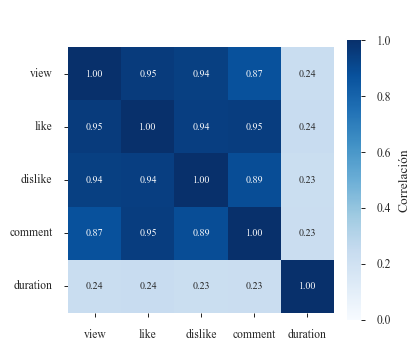

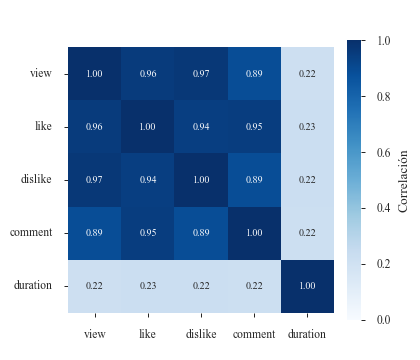

In [37]:
# Visualizar correlación de variables (dividido en Pearson log1p y Spearman de una columna)
short_labels = ['view', 'like', 'dislike', 'comment', 'duration']

df_corr_log = np.log1p(df_train[numeric_cols])
df_corr_log.columns = short_labels
corr_matrix_log = df_corr_log.corr(method='pearson')

df_corr_orig = df_train[numeric_cols].copy()
df_corr_orig.columns = short_labels
corr_matrix_spearman = df_corr_orig.corr(method='spearman')

# 1. Pearson (log1p)
fig, ax = plt.subplots(figsize=(COL, 3.0))
fig.get_layout_engine().set(rect=(0.01, 0, 0.98, 1))
sns.heatmap(corr_matrix_log, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, ax=ax, square=True, cbar=True,
            cbar_kws={'shrink': 0.8, 'aspect': 20, 'label': 'Correlación'},
            annot_kws={'size': 6})
ax.tick_params(axis='y', rotation=0)

plt.savefig('images_overleaf/correlacion_pearson_log1p_groundtruth.png')
plt.show()

# 2. Spearman
fig, ax = plt.subplots(figsize=(COL, 3.0))
fig.get_layout_engine().set(rect=(0.01, 0, 0.98, 1))
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, ax=ax, square=True, cbar=True,
            cbar_kws={'shrink': 0.8, 'aspect': 20, 'label': 'Correlación'},
            annot_kws={'size': 6})
ax.tick_params(axis='y', rotation=0)

plt.savefig('images_overleaf/correlacion_spearman_groundtruth.png')
plt.show()

In [38]:
# Prueba de Kruskal-Wallis: ¿la distribución de cada variable numérica
# difiere significativamente entre las categorías de classification_label?
from scipy import stats

print("PRUEBA DE KRUSKAL-WALLIS POR VARIABLE Y CATEGORÍA")
print("="*70)

for col in numeric_cols:
    grupos = [df_train[df_train['classification_label'] == cat][col].dropna()
              for cat in df_train['classification_label'].unique()]
    stat, p_value = stats.kruskal(*grupos)
    significativo = 'Sí' if p_value < 0.05 else 'No'
    print(f"{col:20s} -> H = {stat:8.2f}, p-value = {p_value:.4e}  | ¿Diferencia significativa entre clases? {significativo}")

PRUEBA DE KRUSKAL-WALLIS POR VARIABLE Y CATEGORÍA
view_count           -> H =   523.87, p-value = 3.1998e-113  | ¿Diferencia significativa entre clases? Sí
like_count           -> H =   232.61, p-value = 3.7634e-50  | ¿Diferencia significativa entre clases? Sí
dislike_count        -> H =   399.39, p-value = 2.9958e-86  | ¿Diferencia significativa entre clases? Sí
comment_count        -> H =   150.65, p-value = 1.9085e-32  | ¿Diferencia significativa entre clases? Sí
duration_seconds     -> H =   129.94, p-value = 5.5734e-28  | ¿Diferencia significativa entre clases? Sí


**Interpretación de resultados:**

En escala original, duration_seconds no muestra relación relevante con ninguna otra variable (correlaciones entre -0.014 y 0.004): la duración de un video es prácticamente independiente de qué tan viral se vuelve.

En escala `log1p`, view_count, like_count, dislike_count y comment_count están fuertemente correlacionadas entre sí (entre 0.87 y 0.96). Esto es esperable: un video con más vistas casi siempre acumula proporcionalmente más likes, dislikes y comentarios. En términos prácticos, esto implica que usar las cuatro variables crudas como features por separado aportaría información muy redundante (multicolinealidad). Por eso el plan de feature engineering prioriza ratios (likes/views, comments/views) en lugar de los conteos crudos.

La prueba de Kruskal-Wallis mostró diferencias estadísticamente significativas entre clases para las cinco variables numéricas (p-value < 0.05 en todos los casos). Con casi 4,800 videos, incluso diferencias pequeñas pueden resultar significativas, así que este resultado funciona como un primer filtro —ninguna variable se descarta todavía— y no como prueba definitiva de que sean predictores fuertes; eso se confirmará en la Etapa 2 al medir la importancia de features con el modelo entrenado.

# PARTE 2: EDA BREVE DE DATASETS ADICIONALES (COMPROBACIÓN DE CONSISTENCIA)


## 15. Carga de Muestras de Datasets Adicionales

In [39]:
# Función para cargar muestra de archivos JSON.gz
def load_jsonl_gz_sample(file_path, sample_size=1000):
    data = []
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= sample_size:
                break
            data.append(json.loads(line))
    return data

# Función para cargar muestra de datasets multipart
def load_multipart_jsonl_sample(base_path, folder_name, sample_size=1000):
    data = []
    folder_path = os.path.join(base_path, folder_name)
    
    if os.path.exists(folder_path):
        part_files = sorted([f for f in os.listdir(folder_path) if f.startswith('part_') and f.endswith('.json.gz')])
        if part_files:
            part_path = os.path.join(folder_path, part_files[0])
            print(f"  Cargando las primeras {sample_size} líneas de {part_files[0]}...")
            data = load_jsonl_gz_sample(part_path, sample_size)
    else:
        print(f"  Carpeta {folder_name} no encontrada")
    return data

# Cargar las primeras 1,000 líneas de datasets adicionales para comprobación de consistencia
print("Cargando las PRIMERAS 1,000 LÍNEAS de datasets adicionales para COMPROBACIÓN DE CONSISTENCIA...")

print("Cargando líneas de elsagate_related_videos...")
elsagate_sample = load_multipart_jsonl_sample(DATA_PATH, 'elsagate_related_videos_parts', sample_size=1000)
print(f"• elsagate_related_videos: {len(elsagate_sample)} líneas cargadas")

print("Cargando líneas de other_child_related_videos...")
other_child_sample = load_multipart_jsonl_sample(DATA_PATH, 'other_child_related_videos_parts', sample_size=1000)
print(f"• other_child_related_videos: {len(other_child_sample)} líneas cargadas")

print("Cargando líneas de random_videos...")
random_sample = load_multipart_jsonl_sample(DATA_PATH, 'random_videos_parts', sample_size=1000)
print(f"• random_videos: {len(random_sample)} líneas cargadas")

print("Cargando líneas de popular_videos...")
popular_path = os.path.join(DATA_PATH, 'popular_videos.json.gz')
popular_sample = load_jsonl_gz_sample(popular_path, sample_size=1000)
print(f"• popular_videos: {len(popular_sample)} líneas cargadas")

print(f"\nEstas primeras 1,000 líneas se usarán para comprobación de consistencia con el modelo entrenado (sin etiquetas humanas)")


Cargando las PRIMERAS 1,000 LÍNEAS de datasets adicionales para COMPROBACIÓN DE CONSISTENCIA...
Cargando líneas de elsagate_related_videos...
  Cargando las primeras 1000 líneas de part_01.json.gz...
• elsagate_related_videos: 1000 líneas cargadas
Cargando líneas de other_child_related_videos...
  Cargando las primeras 1000 líneas de part_01.json.gz...
• other_child_related_videos: 1000 líneas cargadas
Cargando líneas de random_videos...
  Cargando las primeras 1000 líneas de part_01.json.gz...
• random_videos: 1000 líneas cargadas
Cargando líneas de popular_videos...
• popular_videos: 1000 líneas cargadas

Estas primeras 1,000 líneas se usarán para comprobación de consistencia con el modelo entrenado (sin etiquetas humanas)


## 16. EDA: elsagate_related_videos (Primeras 1,000 líneas)


In [40]:
# Análisis breve de elsagate_related_videos (primeras 1,000 líneas)
print("ELSAGATE_RELATED_VIDEOS (MUESTRA DE 1,000 LÍNEAS)")
print("="*50)

gt_ids = set(df_train['video_id'])
in_gt = [v for v in elsagate_sample if v.get('id', '') in gt_ids]
not_in_gt = [v for v in elsagate_sample if v.get('id', '') not in gt_ids]

print(f"Total en muestra: {len(elsagate_sample)}")
print(f"En Ground Truth (seeds): {len(in_gt)}")
print(f"Fuera de Ground Truth (recomendados): {len(not_in_gt)}")

# Distribución de predicciones
pred_labels = [v.get('prediction', 'unknown') for v in elsagate_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución total de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

gt_preds = Counter([v.get('prediction', '') for v in in_gt])
non_gt_preds = Counter([v.get('prediction', '') for v in not_in_gt])
print(f"\nPredicciones en videos del GT (N={len(in_gt)}): {dict(gt_preds)}")
print(f"Predicciones en videos fuera de GT (N={len(not_in_gt)}): {dict(non_gt_preds)}")


ELSAGATE_RELATED_VIDEOS (MUESTRA DE 1,000 LÍNEAS)
Total en muestra: 1000
En Ground Truth (seeds): 780
Fuera de Ground Truth (recomendados): 220

Distribución total de predicciones (muestra):
  appropriate: 527 (52.7%)
  inappropriate: 473 (47.3%)

Predicciones en videos del GT (N=780): {'appropriate': 308, 'inappropriate': 472}
Predicciones en videos fuera de GT (N=220): {'appropriate': 219, 'inappropriate': 1}


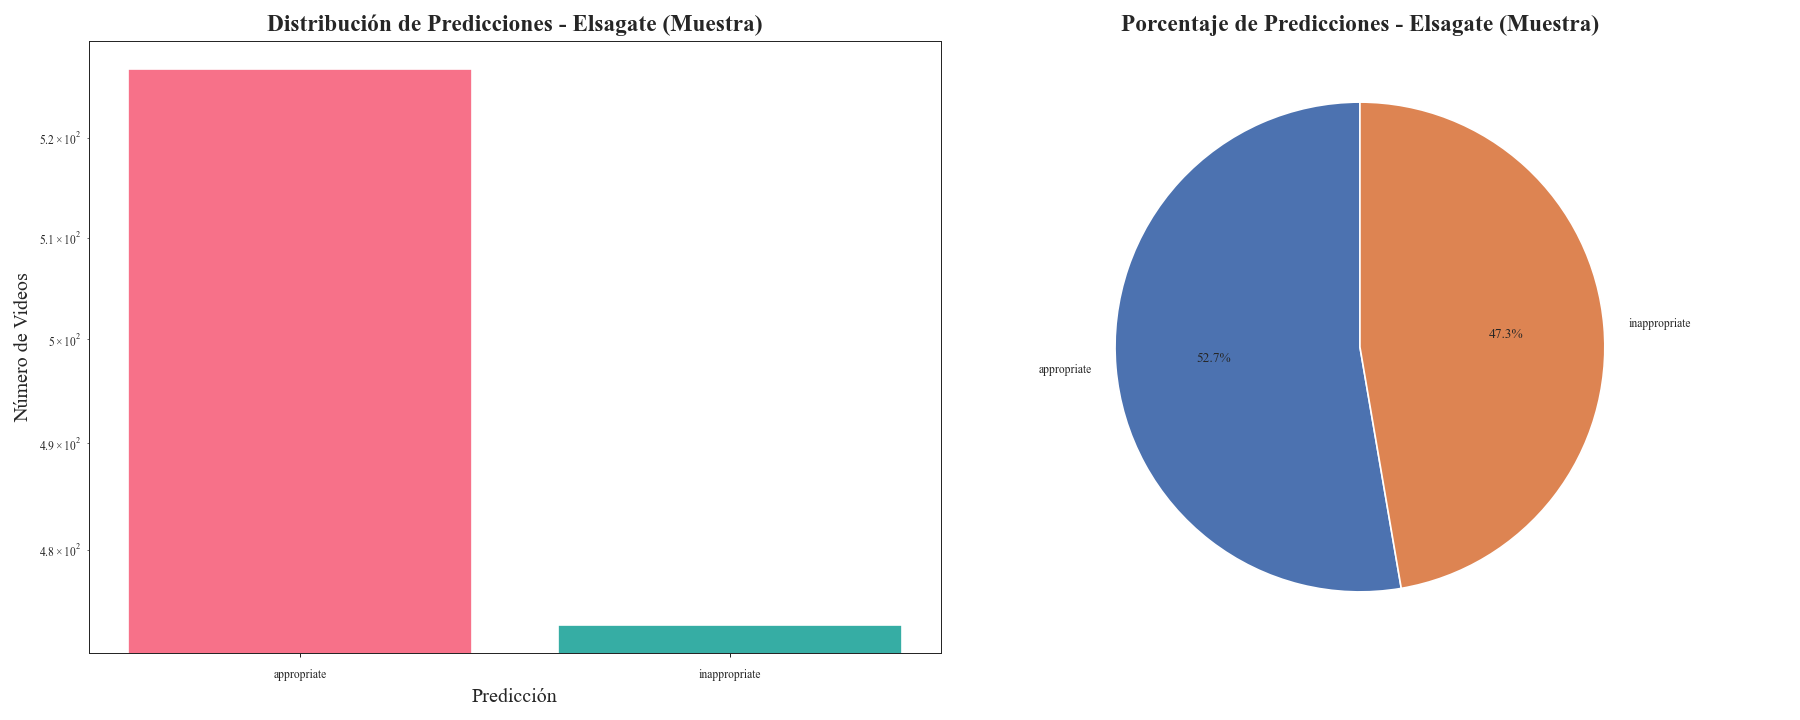

In [41]:
# Visualizar distribución de predicciones en elsagate (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_elsagate = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_elsagate.index, df_pred_elsagate['count'], color=sns.color_palette("husl", len(df_pred_elsagate)))
    axes[0].set_title("Distribución de Predicciones - Elsagate (Muestra)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicción", fontsize=12)
    axes[0].set_ylabel("Número de Videos", fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_elsagate['count'], labels=df_pred_elsagate.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Porcentaje de Predicciones - Elsagate (Muestra)", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de elsagate")

## 17. EDA: other_child_related_videos (Primeras 1,000 líneas)


In [42]:
# Análisis breve de other_child_related_videos (primeras 1,000 líneas)
print("OTHER_CHILD_RELATED_VIDEOS (MUESTRA DE 1,000 LÍNEAS)")
print("="*50)

in_gt = [v for v in other_child_sample if v.get('id', '') in gt_ids]
not_in_gt = [v for v in other_child_sample if v.get('id', '') not in gt_ids]

print(f"Total en muestra: {len(other_child_sample)}")
print(f"En Ground Truth (seeds): {len(in_gt)}")
print(f"Fuera de Ground Truth (recomendados): {len(not_in_gt)}")

pred_labels = [v.get('prediction', 'unknown') for v in other_child_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución total de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

gt_preds = Counter([v.get('prediction', '') for v in in_gt])
non_gt_preds = Counter([v.get('prediction', '') for v in not_in_gt])
print(f"\nPredicciones en videos del GT (N={len(in_gt)}): {dict(gt_preds)}")
print(f"Predicciones en videos fuera de GT (N={len(not_in_gt)}): {dict(non_gt_preds)}")


OTHER_CHILD_RELATED_VIDEOS (MUESTRA DE 1,000 LÍNEAS)
Total en muestra: 1000
En Ground Truth (seeds): 70
Fuera de Ground Truth (recomendados): 930

Distribución total de predicciones (muestra):
  appropriate: 985 (98.5%)
  inappropriate: 15 (1.5%)

Predicciones en videos del GT (N=70): {'appropriate': 55, 'inappropriate': 15}
Predicciones en videos fuera de GT (N=930): {'appropriate': 930}


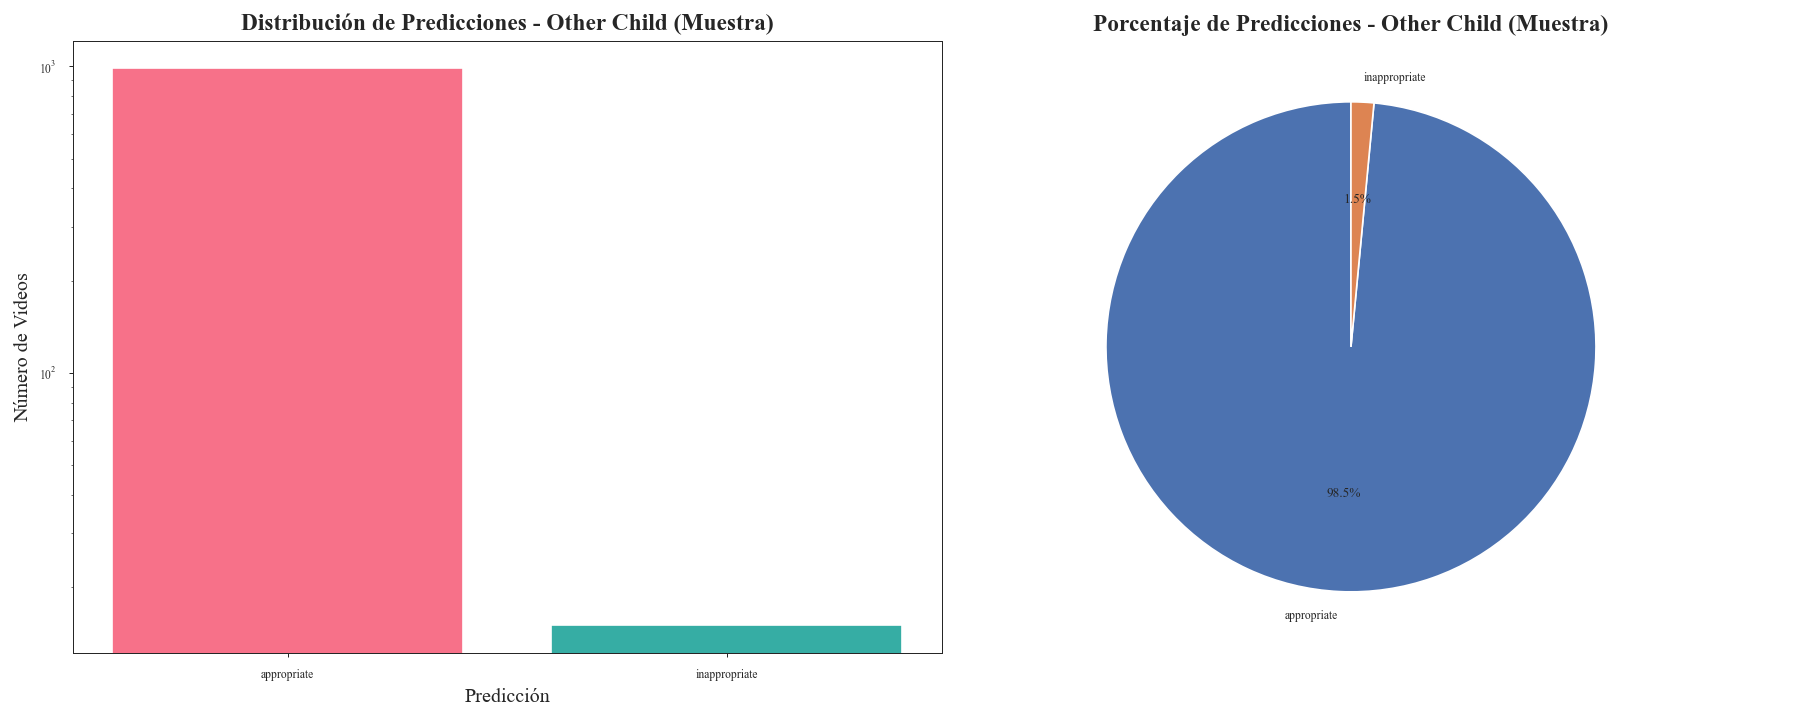

In [43]:
# Visualizar distribución de predicciones en other_child (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_other = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_other.index, df_pred_other['count'], color=sns.color_palette("husl", len(df_pred_other)))
    axes[0].set_title("Distribución de Predicciones - Other Child (Muestra)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicción", fontsize=12)
    axes[0].set_ylabel("Número de Videos", fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_other['count'], labels=df_pred_other.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Porcentaje de Predicciones - Other Child (Muestra)", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de other_child")

## 18. EDA: random_videos (Primeras 1,000 líneas)


In [44]:
# Análisis breve de random_videos (primeras 1,000 líneas)
print("RANDOM_VIDEOS (MUESTRA DE 1,000 LÍNEAS)")
print("="*50)

in_gt = [v for v in random_sample if v.get('id', '') in gt_ids]
not_in_gt = [v for v in random_sample if v.get('id', '') not in gt_ids]

print(f"Total en muestra: {len(random_sample)}")
print(f"En Ground Truth (seeds): {len(in_gt)}")
print(f"Fuera de Ground Truth (recomendados): {len(not_in_gt)}")

pred_labels = [v.get('prediction', 'unknown') for v in random_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución total de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

gt_preds = Counter([v.get('prediction', '') for v in in_gt])
non_gt_preds = Counter([v.get('prediction', '') for v in not_in_gt])
print(f"\nPredicciones en videos del GT (N={len(in_gt)}): {dict(gt_preds)}")
print(f"Predicciones en videos fuera de GT (N={len(not_in_gt)}): {dict(non_gt_preds)}")


RANDOM_VIDEOS (MUESTRA DE 1,000 LÍNEAS)
Total en muestra: 1000
En Ground Truth (seeds): 34
Fuera de Ground Truth (recomendados): 966

Distribución total de predicciones (muestra):
  appropriate: 997 (99.7%)
  inappropriate: 3 (0.3%)

Predicciones en videos del GT (N=34): {'appropriate': 31, 'inappropriate': 3}
Predicciones en videos fuera de GT (N=966): {'appropriate': 966}


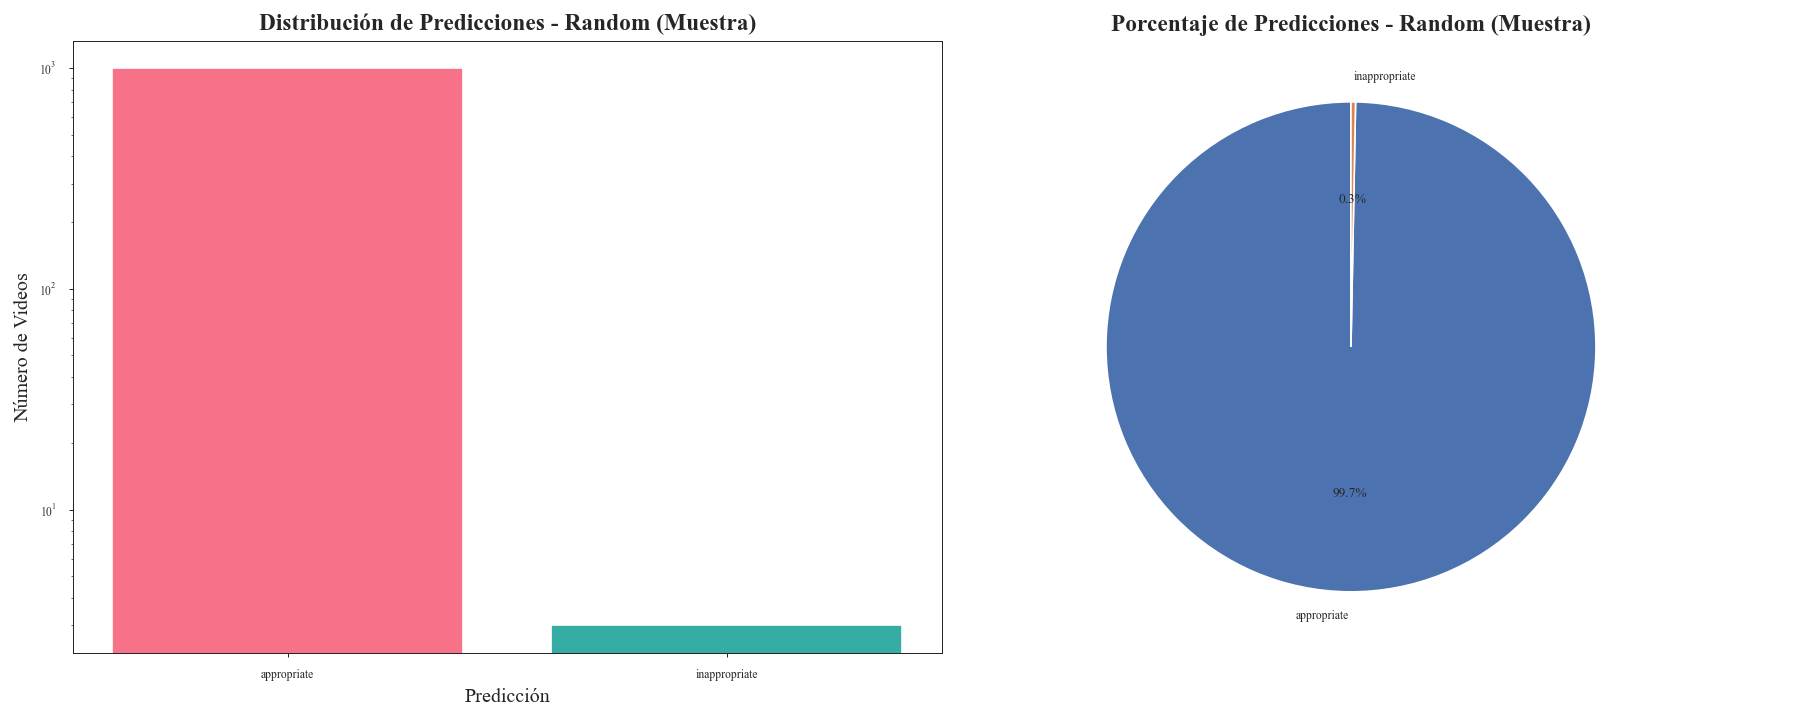

In [45]:
# Visualizar distribución de predicciones en random (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_random = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_random.index, df_pred_random['count'], color=sns.color_palette("husl", len(df_pred_random)))
    axes[0].set_title("Distribución de Predicciones - Random (Muestra)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicción", fontsize=12)
    axes[0].set_ylabel("Número de Videos", fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_random['count'], labels=df_pred_random.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Porcentaje de Predicciones - Random (Muestra)", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de random")

## 19. EDA: popular_videos (Primeras 1,000 líneas)


In [46]:
# Análisis breve de popular_videos (primeras 1,000 líneas)
print("POPULAR_VIDEOS (MUESTRA DE 1,000 LÍNEAS)")
print("="*50)

in_gt = [v for v in popular_sample if v.get('id', '') in gt_ids]
not_in_gt = [v for v in popular_sample if v.get('id', '') not in gt_ids]

print(f"Total en muestra: {len(popular_sample)}")
print(f"En Ground Truth (seeds): {len(in_gt)}")
print(f"Fuera de Ground Truth (recomendados): {len(not_in_gt)}")

pred_labels = [v.get('prediction', 'unknown') for v in popular_sample if v.get('prediction', '')]
pred_counter = Counter(pred_labels)
print(f"\nDistribución total de predicciones (muestra):")
for label, count in pred_counter.most_common():
    print(f"  {label}: {count} ({count/len(pred_labels)*100:.1f}%)")

gt_preds = Counter([v.get('prediction', '') for v in in_gt])
non_gt_preds = Counter([v.get('prediction', '') for v in not_in_gt])
print(f"\nPredicciones en videos del GT (N={len(in_gt)}): {dict(gt_preds)}")
print(f"Predicciones en videos fuera de GT (N={len(not_in_gt)}): {dict(non_gt_preds)}")


POPULAR_VIDEOS (MUESTRA DE 1,000 LÍNEAS)
Total en muestra: 1000
En Ground Truth (seeds): 490
Fuera de Ground Truth (recomendados): 510

Distribución total de predicciones (muestra):
  appropriate: 973 (97.3%)
  inappropriate: 27 (2.7%)

Predicciones en videos del GT (N=490): {'appropriate': 463, 'inappropriate': 27}
Predicciones en videos fuera de GT (N=510): {'appropriate': 510}


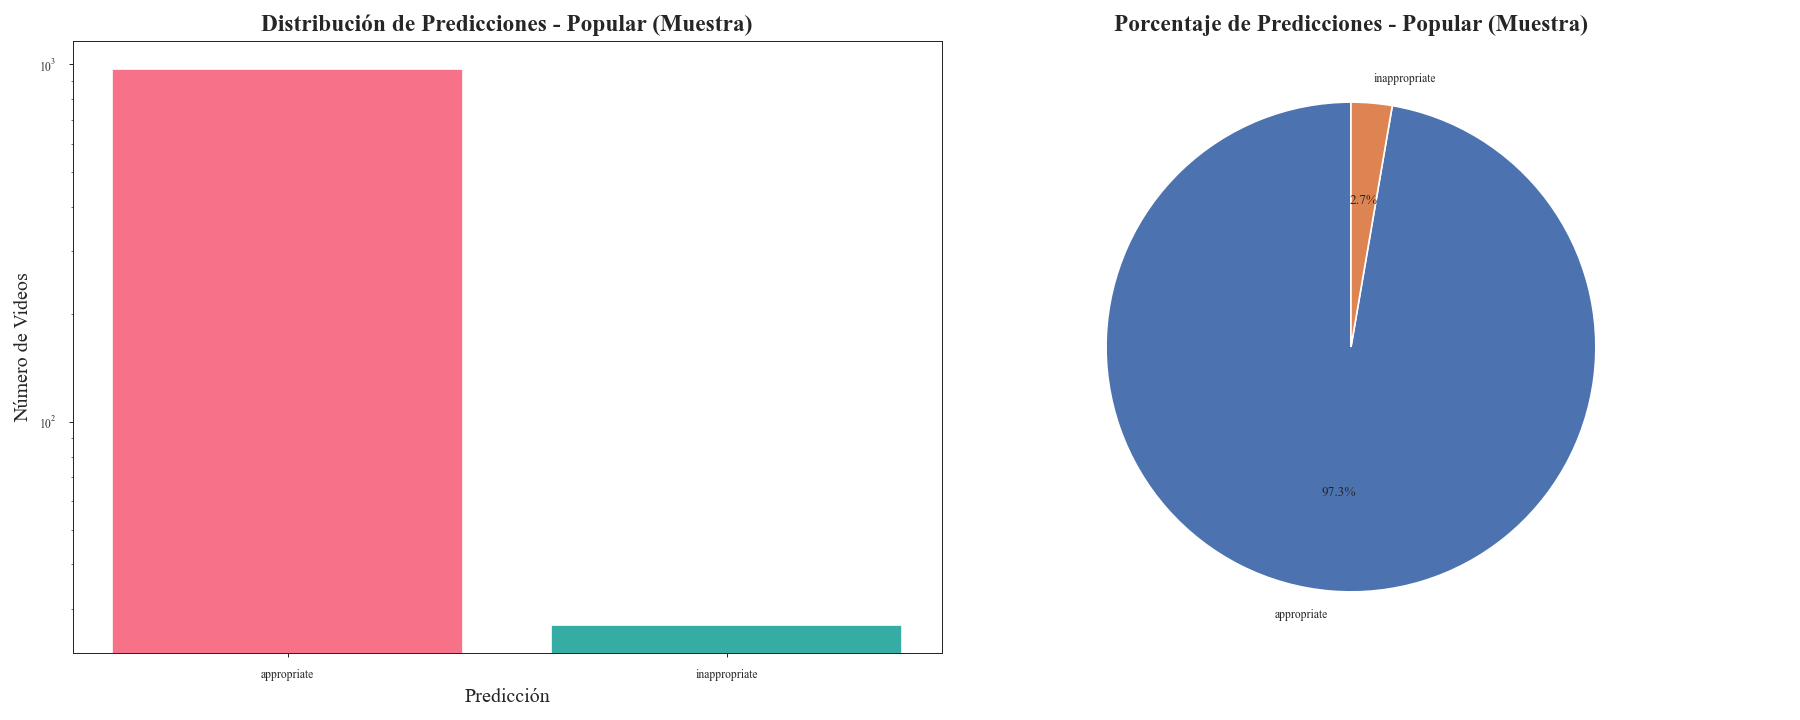

In [47]:
# Visualizar distribución de predicciones en popular (muestra)
if pred_counter:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras de predicciones
    df_pred_popular = pd.DataFrame.from_dict(pred_counter, orient='index', columns=['count'])
    bars = axes[0].bar(df_pred_popular.index, df_pred_popular['count'], color=sns.color_palette("husl", len(df_pred_popular)))
    axes[0].set_title('Distribución de Predicciones - Popular (Muestra)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicción', fontsize=12)
    axes[0].set_ylabel('Número de Videos', fontsize=12)
    axes[0].set_yscale('log')

    # Pie chart
    axes[1].pie(df_pred_popular['count'], labels=df_pred_popular.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Porcentaje de Predicciones - Popular (Muestra)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para visualizar en la muestra de popular")

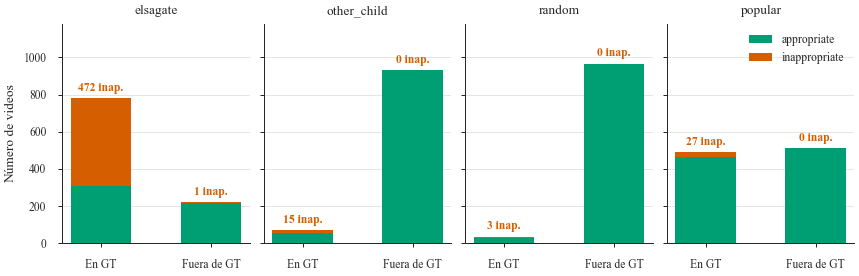

In [48]:
# Visualizar distribución de predicciones en datasets adicionales (en GT vs. fuera de GT)
gt_ids_set = set(df_train['video_id'])
datasets_info = [
    ('elsagate', elsagate_sample),
    ('other_child', other_child_sample),
    ('random', random_sample),
    ('popular', popular_sample)
]

fig, axes = plt.subplots(1, 4, figsize=(DOBLE, 2.3), sharey=True)
apply_layout_g3(fig)

for i, (name, sample) in enumerate(datasets_info):
    ax = axes[i]
    in_gt_items = [v for v in sample if v.get('id', '') in gt_ids_set]
    out_gt_items = [v for v in sample if v.get('id', '') not in gt_ids_set]
    
    in_app = sum(1 for v in in_gt_items if v.get('prediction') == 'appropriate')
    in_inapp = sum(1 for v in in_gt_items if v.get('prediction') == 'inappropriate')
    
    out_app = sum(1 for v in out_gt_items if v.get('prediction') == 'appropriate')
    out_inapp = sum(1 for v in out_gt_items if v.get('prediction') == 'inappropriate')
    
    x_labels = ['En GT', 'Fuera de GT']
    app_vals = [in_app, out_app]
    inapp_vals = [in_inapp, out_inapp]
    
    ax.bar(x_labels, app_vals, label='appropriate', color='#009E73', width=0.55, edgecolor='none')
    ax.bar(x_labels, inapp_vals, bottom=app_vals, label='inappropriate', color='#D55E00', width=0.55, edgecolor='none')
    
    for idx_bar, inapp_cnt in enumerate(inapp_vals):
        total_h = app_vals[idx_bar] + inapp_vals[idx_bar]
        ax.text(idx_bar, total_h + 25, f"{inapp_cnt} inap.", ha='center', va='bottom', fontsize=7, fontweight='bold', color='#D55E00')
    
    ax.set_title(name)
    ax.set_ylim(0, 1180)
    ax.grid(axis='y', color='0.85', linewidth=0.4)
    ax.set_axisbelow(True)
    if i == 0:
        ax.set_ylabel('Número de videos')
    if i == 3:
        ax.legend(frameon=False, loc='upper right')
    sns.despine(ax=ax)

plt.savefig('images_overleaf/distrib_predicciones_adicionales.png')
plt.show()

## 20. Análisis de Posible Fuga de Datos (Data Leakage)

### Metodología: verificación de fuga de datos (data leakage)

Para esta sección implementamos cuatro verificaciones para descartar que el modelo, durante el entrenamiento, tenga acceso sin querer a información que no estaría disponible al hacer una predicción real sobre un video nuevo. Cuando esto ocurre, las métricas de validación se ven artificialmente mejores de lo que el modelo realmente lograría en producción.

La primera verificación revisa si existen columnas que ya codifican directamente la etiqueta o una pista fuerte de ella. La segunda revisa si hay videos repetidos dentro del propio ground truth. La tercera revisa si los videos de las muestras "de prueba" (elsagate_related, other_child, random, popular) ya fueron vistos durante el entrenamiento. La cuarta revisa si ciertos canales de YouTube concentran videos de una sola clase, lo cual podría hacer que el modelo memorice el canal en lugar de aprender patrones de contenido generalizables.

In [49]:
# 1. Verificar si existen columnas que codifiquen directamente la etiqueta o predicciones
# del clasificador original (deben excluirse como features en el modelado propio)
columnas_sospechosas = ['prediction', 'is_ground_truth']

print("Columnas potencialmente filtradoras de información en el ground truth:")
print("="*70)
for col in columnas_sospechosas:
    if col in df_train.columns:
        print(f"\n'{col}' está presente en df_train")
        print(df_train[col].value_counts(dropna=False))
    else:
        print(f"\n'{col}' no está presente en df_train (ok, no hay riesgo de fuga por esta vía)")

Columnas potencialmente filtradoras de información en el ground truth:

'prediction' está presente en df_train
prediction
NaN    4797
Name: count, dtype: int64

'is_ground_truth' está presente en df_train
is_ground_truth
1    4797
Name: count, dtype: int64


In [50]:
# 2. Verificar videos duplicados dentro del ground truth
duplicados = df_train['video_id'].duplicated().sum()
print(f"Videos duplicados (mismo video_id) dentro de dataset_groundtruth.csv: {duplicados}")

if duplicados > 0:
    print("\nEjemplos de video_id duplicados:")
    print(df_train[df_train['video_id'].duplicated(keep=False)]
          .sort_values('video_id')[['video_id', 'title', 'classification_label']].head(10))

Videos duplicados (mismo video_id) dentro de dataset_groundtruth.csv: 0


In [51]:
# 3. Verificar solapamiento de video_id entre el ground truth (train) y las muestras
# de los datasets adicionales (contaminación potencial train/test si un mismo video
# aparece en ambos conjuntos). Se prueban distintos nombres de clave por si el JSON
# usa camelCase en vez de snake_case.
def extraer_video_ids(muestra, posibles_keys=('videoId', 'video_id', 'id')):
    ids = set()
    for v in muestra:
        for k in posibles_keys:
            if k in v:
                ids.add(v[k])
                break
    return ids

ids_train = set(df_train['video_id'])

muestras_adicionales = {
    'elsagate_related': elsagate_sample,
    'other_child_related': other_child_sample,
    'random_videos': random_sample,
    'popular_videos': popular_sample,
}

print("Solapamiento de video_id entre groundtruth (train) y muestras adicionales:")
print("="*70)
for nombre, muestra in muestras_adicionales.items():
    ids_muestra = extraer_video_ids(muestra)
    interseccion = ids_train & ids_muestra
    print(f"  {nombre:25s}: {len(interseccion)} videos en común (sobre {len(ids_muestra)} ids en la muestra)")

Solapamiento de video_id entre groundtruth (train) y muestras adicionales:
  elsagate_related         : 780 videos en común (sobre 1000 ids en la muestra)
  other_child_related      : 70 videos en común (sobre 1000 ids en la muestra)
  random_videos            : 34 videos en común (sobre 1000 ids en la muestra)
  popular_videos           : 490 videos en común (sobre 1000 ids en la muestra)


In [52]:
# 4. Concentración de videos por canal: evaluación de canales con 12 o más videos (empate séxtuple)
videos_por_canal = df_train.groupby('channel_id').size().sort_values(ascending=False)
canales_multivideo = (videos_por_canal > 1).sum()

print(f"Canales únicos: {df_train['channel_id'].nunique()}")
print(f"Canales con más de un video en el ground truth: {canales_multivideo}")

# Debido a que 6 canales empatan con exactamente 12 videos, evaluamos los 13 canales con >= 12 videos:
canales_top12 = videos_por_canal[videos_por_canal >= 12].index
print(f"\nCanales con 12 o más videos en el ground truth (N = {len(canales_top12)}):\n", videos_por_canal.loc[canales_top12])

ct_top_canales = pd.crosstab(df_train[df_train['channel_id'].isin(canales_top12)]['channel_id'],
                             df_train[df_train['channel_id'].isin(canales_top12)]['classification_label'])
print("\nDistribución de clases en los canales con 12 o más videos:")
print(ct_top_canales)


Canales únicos: 3818
Canales con más de un video en el ground truth: 418

Canales con 12 o más videos en el ground truth (N = 13):
 channel_id
UC9-oOzriEPfpPvjTOAu3Cww    33
UCYEHNnr_6XP-NY738hwXL1g    24
UCIqM7K41ayqdI7PTehEabLQ    19
UCcKJJuOe2tOqgrKw0Gks-sw    16
UCZS-8ZKPVBiKtv3MFmgI00g    13
UCpbqPxSS3NU-DiPNy7ttwLA    13
UC5K8SEF_7GQBedXIjtXLCRg    13
UC3q2YwNGj7ktNf70PqMW72g    12
UC5XyjtgkUGC2jt2q7XoRk5Q    12
UC_5niPa-d35gg88HaS7RrIw    12
UCAOtE1V7Ots4DjM8JLlrYgg    12
UCB5DCrEQdSSE0t7lwK9g48Q    12
UCBzZ9lJmcsPRbiyHPbLYvOA    12
dtype: int64

Distribución de clases en los canales con 12 o más videos:
classification_label      disturbing  suitable
channel_id                                    
UC3q2YwNGj7ktNf70PqMW72g           0        12
UC5K8SEF_7GQBedXIjtXLCRg           0        13
UC5XyjtgkUGC2jt2q7XoRk5Q           0        12
UC9-oOzriEPfpPvjTOAu3Cww          20        13
UCAOtE1V7Ots4DjM8JLlrYgg           0        12
UCB5DCrEQdSSE0t7lwK9g48Q           0        12
UCBzZ

**Resultados y conclusiones sobre Fuga de Datos (Data Leakage):**

1. **Columnas del Proceso de Etiquetado:** La columna `prediction` está completamente vacía en el ground truth (4,797 valores NaN), e `is_ground_truth` es constante (siempre 1). Ninguna de las dos aporta señal predictiva legítima y deben excluirse formalmente del modelado.

2. **Duplicados:** No se identificaron `video_id` duplicados dentro del ground truth (0 duplicados; 4,797 videos únicos).

3. **Solapamiento con Datasets Adicionales:** Se constató que 780 videos de la muestra de `elsagate_related` (78.0%), 490 de `popular_videos` (49.0%), 70 de `other_child_related` (7.0%) y 34 de `random_videos` (3.4%) ya forman parte del ground truth de entrenamiento (seeds). Como los datasets adicionales carecen de etiquetas humanas independientes, **no deben utilizarse como conjunto de evaluación para calcular métricas de desempeño (F1 o exactitud)**. Su rol se restringe a la comprobación de consistencia y análisis de distribución de predicciones, excluyendo estrictamente los videos que ya están en el ground truth para evitar evaluaciones contaminadas.

4. **Concentración de Videos por Canal:** De los 3,818 canales únicos (`channel_id`), 418 tienen más de un video. Al examinar los 13 canales con 12 o más videos (debido a un empate séxtuple en 12 videos), **11 canales concentran el 100% de sus videos en `suitable`**, 1 canal tiene el 91.7% en `suitable` (11 suitable y 1 disturbing) y solo 1 es mixto (20 disturbing y 13 suitable). Esto confirma que, con un split puramente aleatorio por video, un modelo podría memorizar características estilísticas del uploader en lugar de aprender patrones de contenido inapropiado.

**Recomendaciones para la Etapa 2:**
- Excluir `prediction`, `is_ground_truth`, `channel_id`, `channel_title` y `video_id` de las variables predictoras (features).
- Implementar validación cruzada y partición de prueba mediante **`StratifiedGroupKFold`** agrupado por `channel_id` y estratificado por clase.
- Ajustar todas las transformaciones (imputación, escalamiento, TF-IDF y SMOTE) estrictamente solo dentro de los folds de entrenamiento.


## 21. Resumen Final

In [53]:
# Resumen final del análisis exploratorio
print("="*60)
print("RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO")
print("="*60)

print(f"\nDATASET ANOTADO (GROUNDTRUTH):")
print(f"  - Fuente: dataset_groundtruth.csv")
print(f"  - Total videos: {len(df_train):,}")
print(f"  - Clases: {', '.join(label_counts.index)}")
print(f"  - Etiquetas: 100% manuales y confiables")
print(f"  - Canales únicos: {df_train['channel_id'].nunique()} (por ID) / {df_train['channel_title'].nunique()} (por título)")
print(f"  - Tags individuales únicos: {len(set(all_tags_clean)):,} (limpios) / {len(set(all_tags_lower)):,} (minúsculas)")
print(f"  - Uso: ENTRENAMIENTO y evaluación formal (split train/test y validación cruzada)")

print(f"\nDATASETS ADICIONALES (COMPROBACIÓN DE CONSISTENCIA - PRIMERAS 1,000 LÍNEAS):")
gt_ids_set = set(df_train['video_id'])
muestras_dict = [
    ('elsagate_related', elsagate_sample),
    ('other_child_related', other_child_sample),
    ('random_videos', random_sample),
    ('popular_videos', popular_sample)
]
for name, sample in muestras_dict:
    in_cnt = sum(1 for v in sample if v.get('id', '') in gt_ids_set)
    out_cnt = len(sample) - in_cnt
    print(f"  - {name}: {len(sample):,} líneas ({in_cnt} en GT / {out_cnt} fuera de GT)")
print(f"  - Uso: Comprobación de consistencia (sin etiquetas humanas, no para evaluación de métricas)")

print(f"\nESTRATEGIA DEL PROYECTO PARA LA ETAPA 2:")
print(f"  1. Preprocesamiento: log1p en engagement, imputación y vectorización TF-IDF con tags en minúsculas")
print(f"  2. Validación: partición y validación cruzada con StratifiedGroupKFold por channel_id")
print(f"  3. Modelado: baseline de clase mayoritaria y comparación de modelos (Logistic Regression, LightGBM/Random Forest)")
print(f"  4. Métricas: optimización de Macro F1 y Recall en clases críticas (disturbing y restricted)")
print(f"  5. Evaluación cualitativa: comprobación de consistencia en datasets adicionales excluyendo videos de GT")


RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO

DATASET ANOTADO (GROUNDTRUTH):
  - Fuente: dataset_groundtruth.csv
  - Total videos: 4,797
  - Clases: irrelevant, suitable, disturbing, restricted
  - Etiquetas: 100% manuales y confiables
  - Canales únicos: 3818 (por ID) / 3811 (por título)
  - Tags individuales únicos: 40,096 (limpios) / 36,750 (minúsculas)
  - Uso: ENTRENAMIENTO y evaluación formal (split train/test y validación cruzada)

DATASETS ADICIONALES (COMPROBACIÓN DE CONSISTENCIA - PRIMERAS 1,000 LÍNEAS):
  - elsagate_related: 1,000 líneas (780 en GT / 220 fuera de GT)
  - other_child_related: 1,000 líneas (70 en GT / 930 fuera de GT)
  - random_videos: 1,000 líneas (34 en GT / 966 fuera de GT)
  - popular_videos: 1,000 líneas (490 en GT / 510 fuera de GT)
  - Uso: Comprobación de consistencia (sin etiquetas humanas, no para evaluación de métricas)

ESTRATEGIA DEL PROYECTO PARA LA ETAPA 2:
  1. Preprocesamiento: log1p en engagement, imputación y vectorización TF-IDF con tags en min